In [64]:
import seaborn as sns
import matplotlib.cm as cm
from openai import OpenAI
import json
import pandas as pd
from tqdm import tqdm
import yfinance as yf
import pandas_market_calendars as mcal
import datetime
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import expected_returns
from pypfopt import plotting
from pypfopt import risk_models
import numpy as np
import matplotlib.pyplot as plt
import json
from typing import List
from openai import OpenAI
import os
import re
import pandas as pd
from tqdm import tqdm
import yfinance as yf
from gurobipy import Model, GRB, quicksum
import warnings
from dotenv import load_dotenv
import matplotlib.colors as mcolors
from IPython.display import display

In [65]:
# in the /assets folder get every file that beigns with status_ and print their filenames
import os

def print_status_files():
    assets_path = os.path.join(os.getcwd(), "assets")
    
    # Check if the directory exists
    if not os.path.exists(assets_path):
        print(f"Error: Directory {assets_path} does not exist.")
        return
    
    # List all files in the directory
    files = os.listdir(assets_path)
    
    # Filter files that begin with "status_"
    status_files = [file for file in files if file.startswith("status_") and "sparse" not in file]
    
    return status_files

status_files = print_status_files()

In [66]:
def statuses2new_month_indices(statuses):
    new_month_indices = {}  # Use a dictionary to store the last index for each month
    
    for i, status in enumerate(statuses):
        # print(f'looking at {status=}')
        # Check if it's a converged status or a regular iteration
        if "CONVERGED" in status:
            # For converged status, format is "CONVERGED month X iter Y"
            month = int(status.split()[2])
            # Always prefer converged solutions
            new_month_indices[month] = i
        else:
            # For non-converged status, format is "month X iter Y"
            month = int(status.split()[1])
            # Only add if we don't already have a converged solution for this month
            if month not in new_month_indices:
                new_month_indices[month] = i
            # If we have a regular iteration, update only if it's a later iteration
            elif "CONVERGED" not in statuses[new_month_indices[month]]:
                new_month_indices[month] = i
    
    # Convert the dictionary to a sorted list of indices
    return [new_month_indices[month] for month in sorted(new_month_indices.keys())]

In [67]:
import json 

In [68]:
tickers = [
    'NVDA', 'AMD', 'MSFT', 'AAPL', 'INTC', 'PLTR',  # Technology
    'TSLA', 'AMZN', 'SBUX', 'TGT', 'NFLX', 'MCD',  # Consumer Discretionary
    'HOOD', 'BAC', 'JPM', 'MS', 'V', 'SCHW',  # Financials
    'ZG', 'PLD', 'WELL', 'SPG', 'PSA', 'EQR',  # Real Estate
    'GEV', 'XOM', 'DUK', 'NEE', 'EOG', 'SLB',  # Energy
    'TEM', 'UNH', 'PFE', 'MRNA', 'ABBV', 'MDT',  # Healthcare
    'CAT', 'BA', 'LMT', 'DE', 'GD', 'HON',  # Industrials
    'PCT', 'NEM', 'LIN', 'APD', 'FCX', 'MLM',  # Materials
    'GOOG', 'TMUS', 'META', 'DIS', 'VZ', 'CMCSA',  # Communication Services
    'COST', 'PEP', 'WMT', 'KO', 'PG', 'MO'  # Consumer Staples
]

In [69]:
stock_data_path = f"assets/stock_data.json"

def load_data(file_path=stock_data_path):
    """
    Loads JSON data from 'file_path' and returns it as a dictionary.
    """
    with open(file_path, 'r') as fp:
        data = json.load(fp)
    print(f"Data loaded from {file_path}")
    return data

data_loaded = load_data()

Data loaded from assets/stock_data.json


In [70]:
def backtest(weights, statuses):
    # print(f'RECEIVED {statuses=}')
    
    if len(weights) != 12:
        new_month_indices = statuses2new_month_indices(statuses)
        
        weights_to_execute = [weights[i] for i in new_month_indices]
    else:
        weights_to_execute = weights
    
    i = 0
    initial_capital = 10000
    portfolio_value = initial_capital

    portfolio_history = [portfolio_value]
    # Create a DataFrame to track monthly PnL for each ticker
    monthly_pnl = pd.DataFrame(0.0, index=range(12), columns=tickers)

    while i < 11:
        weights = weights_to_execute[i]
        
        # ---- 2) Buy using these weights ----
        shares = []
        buy_prices = []
        initial_capital = portfolio_value

        for j, ticker in enumerate(tickers):
            buy_price = data_loaded[i][ticker]['price']
            buy_prices.append(buy_price)

            allocation = initial_capital * weights[j]  # portion of capital
            shares_bought = allocation / buy_price if buy_price > 0 else 0
            shares.append(shares_bought)

            # Deduct spent cash
            portfolio_value -= shares_bought * buy_price

        # ---- 3) Sell at month i+1 (end of next month), record PnL per ticker ----
        i += 1
        for j, ticker in enumerate(tickers):
            sell_price = data_loaded[i][ticker]['price']
            # PnL for this ticker in month i-1 (e.g. row 0 if i=1 now)
            pnl = shares[j] * (sell_price - buy_prices[j])
            monthly_pnl.loc[i - 1, ticker] = pnl  # store PnL

            # Update portfolio value by the proceeds of selling
            portfolio_value += shares[j] * sell_price

        portfolio_history.append(portfolio_value)

    # print("Final Portfolio Value:", portfolio_value)
    # Return both the total portfolio value history and the per-ticker monthly PnL
    return portfolio_value, portfolio_history, monthly_pnl

In [71]:
llm_returns = []
opt_returns = []
coord_returns = []

for i, status in enumerate(status_files):
    status_file = os.path.join(os.getcwd(), "assets", status)
    with open(status_file, 'r') as f:
        statuses = json.loads(f.read())
    identifier = '_'.join(status.split('_')[1:])[:-5]
    
    # llm returns
    weights_llm_path = os.path.join(os.getcwd(), "assets", f"weights_llm_{identifier}.json")
    with open(weights_llm_path,'r')  as f:
        weights_llm = json.loads(f.read())
    
    new_month_indices = statuses2new_month_indices(statuses)
    
    # print(f"{len(weights_llm)=}\t{len(weights_llm[0])=}\t{len(statuses)=}\t{len(new_month_indices)=}")
    
    portfolio_value, portfolio_history, monthly_pnl = backtest(weights_llm, statuses)
    llm_returns.append(portfolio_value)
    
    # opt returns
    weights_opt_path = os.path.join(os.getcwd(), "assets", f"weights_opt_{identifier}.json")
    with open(weights_opt_path,'r')  as f:
        weights_opt = json.loads(f.read())
    
    new_month_indices = statuses2new_month_indices(statuses)
    
    # print(f"{len(weights_opt)=}\t{len(weights_opt[0])=}\t{len(statuses)=}\t{len(new_month_indices)=}")
    
    portfolio_value, portfolio_history, monthly_pnl = backtest(weights_opt, statuses)
    opt_returns.append(portfolio_value)
    
    # coord returns
    weights_coord_path = os.path.join(os.getcwd(), "assets", f"weights_coord_{identifier}.json")
    with open(weights_coord_path,'r')  as f:
        weights_coord = json.loads(f.read())
    weights_coord = [w[1:] for w in weights_coord]
    
    new_month_indices = statuses2new_month_indices(statuses)
    
    # print(f"{len(weights_coord)=}\t{len(weights_coord[0])=}\t{len(statuses)=}\t{len(new_month_indices)=}")
    
    portfolio_value, portfolio_history, monthly_pnl = backtest(weights_coord, statuses)
    coord_returns.append(portfolio_value)

In [72]:
llm_returns = [l/10000 for l in llm_returns]
coord_returns = [c/10000 for c in coord_returns]

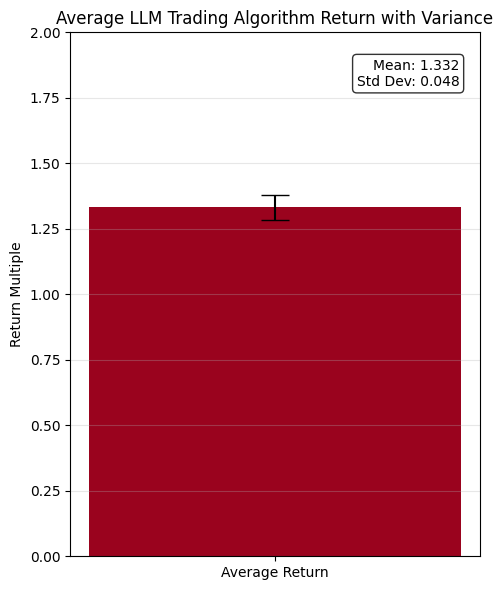

In [73]:
# Calculate mean and standard deviation
mean_return = np.mean(llm_returns)
std_return = np.std(llm_returns)

# Create figure and axis
plt.figure(figsize=(5, 6))

# Create a single skinnier bar for the mean
plt.bar(['Average Return'], [mean_return], color='#9a031e', 
        yerr=std_return, capsize=10, width=0.3)

# Add labels and title
plt.ylabel('Return Multiple')
plt.title('Average LLM Trading Algorithm Return with Variance')
plt.ylim(0, mean_return + 3*std_return)  # Set y-limit to show error bar clearly
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 2)  
# Add text annotation in the upper right corner of the plot
plt.text(0.95, 0.95, f'Mean: {mean_return:.3f}\nStd Dev: {std_return:.3f}', 
         transform=plt.gca().transAxes, ha='right', va='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Show plot
plt.tight_layout()
plt.savefig('YYY/average_llm_return_with_variance.png', dpi=300, bbox_inches='tight')
plt.show()


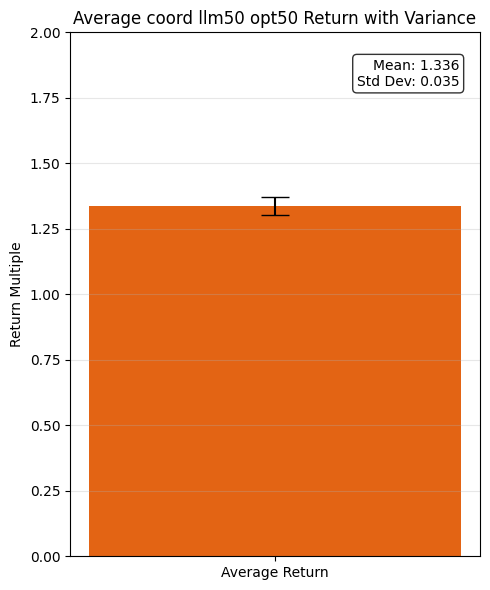

In [74]:
# Calculate mean and standard deviation
mean_return = np.mean(coord_returns)
std_return = np.std(coord_returns)

# Create figure and axis
plt.figure(figsize=(5, 6))

# Create a single skinnier bar for the mean
plt.bar(['Average Return'], [mean_return], color='#e36414', 
        yerr=std_return, capsize=10, width=0.3)

# Add labels and title
plt.ylabel('Return Multiple')
plt.title('Average coord llm50 opt50 Return with Variance')
plt.ylim(0, mean_return + 3*std_return)  # Set y-limit to show error bar clearly
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 2)  
# Add text annotation in the upper right corner of the plot
plt.text(0.95, 0.95, f'Mean: {mean_return:.3f}\nStd Dev: {std_return:.3f}', 
         transform=plt.gca().transAxes, ha='right', va='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Show plot
plt.tight_layout()
plt.savefig('YYY/average_coord_llm50_opt50_return_with_variance.png', dpi=300, bbox_inches='tight')
plt.show()


In [75]:
# 5f0f40 opt, 9a031e llm, fb8b24 opt25-llm75, e36414 opt50-llm50, 0f4c5c coord_llm25_opt75_statuses